In [9]:
import gensim
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import string
import nltk
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [3]:
# Download necessary NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
# Sample corpus: A small example legal text corpus (replace this with your own data)
corpus = [
    "The plaintiff has filed a lawsuit against the defendant for breach of contract.",
    "The court will hear arguments on the motion for summary judgment.",
    "The lawyer presented evidence that supported the claim of negligence.",
    "The defendant's counsel argued that the case should be dismissed on procedural grounds.",
    "The judge ruled in favor of the plaintiff, awarding damages."
]


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [4]:
# Preprocess the corpus: tokenization, removing stop words and punctuation
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    # Tokenize the text
    tokens = word_tokenize(text.lower())  # lowercasing to ensure uniformity
    # Remove stop words and punctuation
    tokens = [word for word in tokens if word not in stop_words and word not in string.punctuation]
    return tokens

# Preprocess the entire corpus
processed_corpus = [preprocess_text(doc) for doc in corpus]

# Train Word2Vec model
print("Training Word2Vec model...")
model = Word2Vec(sentences=processed_corpus,
vector_size=100, window=5, min_count=1, sg=0, workers=4)

# Save the trained model (optional)
model.save("legal_word2vec.model")

Training Word2Vec model...


In [5]:
# Explore the trained embeddings: Find the most similar words to a given word
def find_similar_words(word, top_n=5):
    try:
        similar_words = model.wv.most_similar(word, topn=top_n)
        print(f"Most similar words to '{word}':")
        for similar_word, similarity in similar_words:
            print(f"{similar_word}: {similarity}")
    except KeyError:
        print(f"Word '{word}' not found in the vocabulary.")


Most similar words to 'plaintiff':
breach: 0.1889091432094574
motion: 0.18855372071266174
negligence: 0.1606462597846985
presented: 0.15925753116607666
's: 0.13724736869335175
Most similar words to 'defendant':
supported: 0.21894945204257965
dismissed: 0.216180220246315
lawsuit: 0.19547954201698303
breach: 0.09942276775836945
counsel: 0.09307420998811722


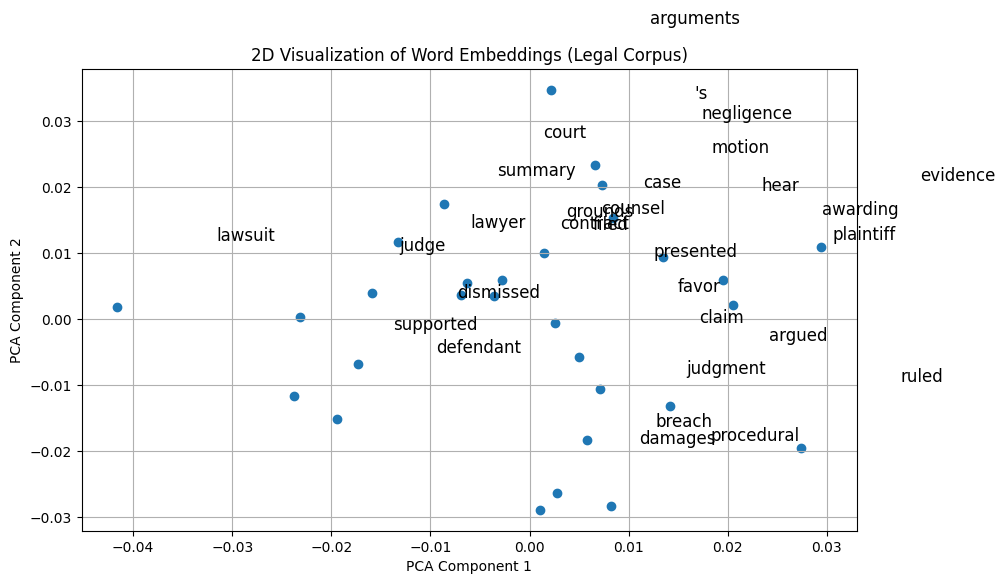

In [6]:
# Example: Find similar words to 'plaintiff'
find_similar_words('plaintiff')

# Example: Find similar words to 'defendant'
find_similar_words('defendant')
# Extract vectors and corresponding words
words = list(model.wv.index_to_key)
vectors = [model.wv[word] for word in words]

# Reduce dimensionality to 2D using PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(vectors)

# Plot the embeddings in 2D
plt.figure(figsize=(10, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1])

# Annotate the words
for i, word in enumerate(words):
    plt.text(pca_result[i, 0] + 0.01, pca_result[i, 1] + 0.01, word, fontsize=12)

plt.title("2D Visualization of Word Embeddings (Legal Corpus)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()